# --------- ASSIGNMENT 6 (AI) - CLUSTERING ANALYSIS -----------

### Understanding and Implementing K-Means and Hierarchical Algorithms

**Objective:**

The objective of this assignment is to introduce to various clustering algorithms, including K-Means, and hierarchical and provide hands-on experience in applying these techniques to a real-world dataset.

**Datasets:**

Used Bike Sharing Demand dataset that I have got in DS-Project.

**Data Preprocessing:**

1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.
2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.
3.	Use multiple visualizations to understand the hidden patterns in the dataset

**Implementing Clustering Algorithms:**

* Implement the K-Means and hierarchical algorithms using a programming language such as Python with libraries like scikit-learn or MATLAB.
* Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.
* Experiment with different parameter settings for hierarchical clustering (e.g., linkage criteria), K-means (Elbow curve for different K values) evaluate the clustering results.

**Cluster Analysis and Interpretation:**

* Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy.cluster.hierarchy import dendrogram, linkage

**Data Preprocessing:**

1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.
2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.
3.	Use multiple visualizations to understand the hidden patterns in the dataset

In [48]:
# ====================================================
# 1. Loading Dataset
# ====================================================

df=pd.read_csv('Dataset.csv')

In [49]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,4,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   instant     17379 non-null  int64 
 1   dteday      17379 non-null  object
 2   season      17379 non-null  object
 3   yr          17379 non-null  object
 4   mnth        17379 non-null  object
 5   hr          17379 non-null  int64 
 6   holiday     17379 non-null  object
 7   weekday     17379 non-null  int64 
 8   workingday  17379 non-null  object
 9   weathersit  17379 non-null  object
 10  temp        17379 non-null  object
 11  atemp       17379 non-null  object
 12  hum         17379 non-null  object
 13  windspeed   17379 non-null  object
 14  casual      17379 non-null  object
 15  registered  17379 non-null  object
 16  cnt         17379 non-null  int64 
dtypes: int64(4), object(13)
memory usage: 2.3+ MB


In [51]:
# ====================================================
# 2. Data Cleaning
# ====================================================

# Replace '?' with NaN

df.replace('?',np.nan, inplace=True)

In [52]:
# Convert numeric column to float

num_cols = ['temp', 'atemp', 'hum', 'windspeed']
for col in num_cols:
  df[col] = df[col].astype(float)

In [53]:
# Fill missing values with mean

df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

In [54]:
# Drop unnecessary columns

df = df.drop(columns=['instant', 'dteday'], errors='ignore')
df.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.810000,0.0,3,13,16
1,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.800000,0.0,8,32,40
2,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,0.627208,0.0,5,27,32
3,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.750000,0.0,3,10,13
4,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.750000,0.0,0,1,1


In [55]:
# ====================================================
# 3. Encode Categorical Data
# ====================================================

cat_cols = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']

le = LabelEncoder()
for col in cat_cols:
  df[col] = le.fit_transform(df[col])
  df[col]

df.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,0,0,0,0,6,0,0,0.24,0.2879,0.810000,0.0,3,13,16
1,1,0,0,1,0,6,0,0,0.22,0.2727,0.800000,0.0,8,32,40
2,1,0,0,2,0,6,0,0,0.22,0.2727,0.627208,0.0,5,27,32
3,1,0,0,3,0,6,0,0,0.24,0.2879,0.750000,0.0,3,10,13
4,1,0,0,4,0,6,0,0,0.24,0.2879,0.750000,0.0,0,1,1


In [56]:
# ====================================================
# 4. Feature Selection
# ====================================================

X = df.drop(columns = ['cnt'])        # Remove target column

In [57]:
# ====================================================
# 5. Feature Scaling
# ====================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

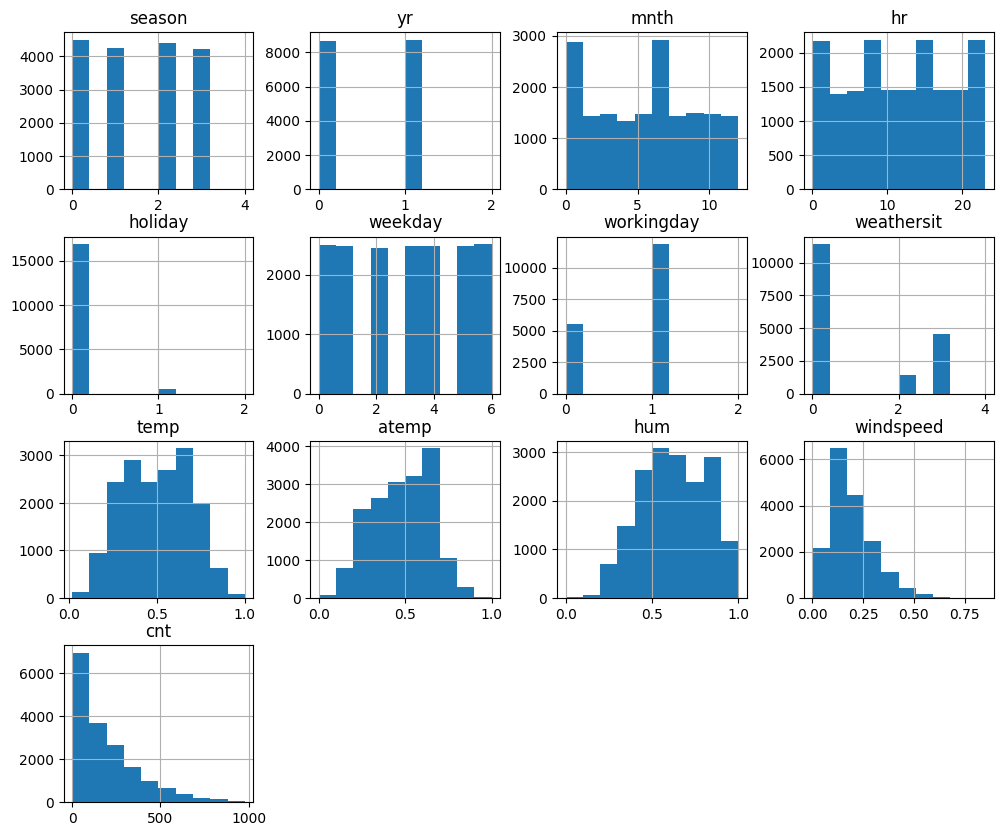

In [58]:
# ====================================================
# 6. Exploratory Data Analysis
# ====================================================

df.hist(figsize=(12,10))
plt.show()

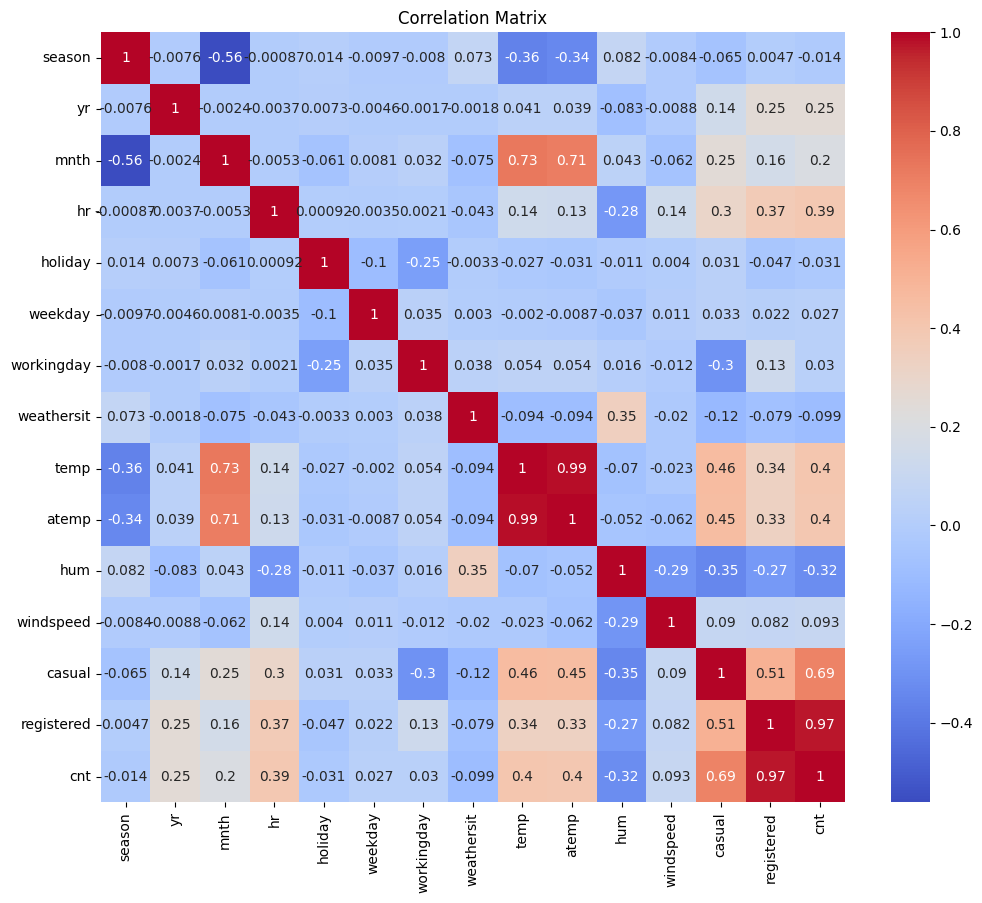

In [59]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Implementing Clustering Algorithms:**

* Implement the K-Means and hierarchical algorithms using a programming language such as Python with libraries like scikit-learn or MATLAB.
* Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.
* Experiment with different parameter settings for hierarchical clustering (e.g., linkage criteria), K-means (Elbow curve for different K values) evaluate the clustering results.

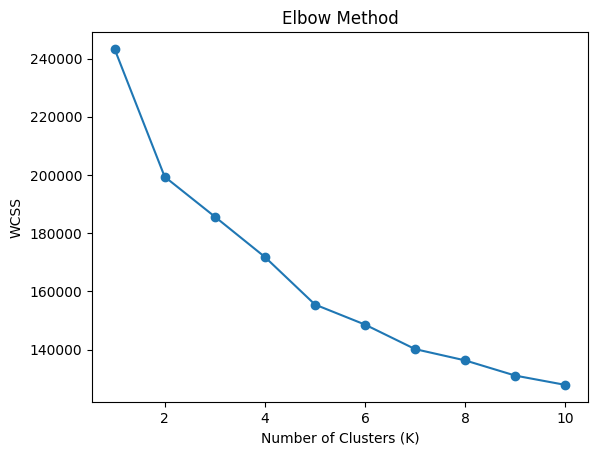

In [60]:
# ====================================================
# 7. K - Means (Elbow Method)
# ====================================================

# Handle potential NaNs in X_scaled before fitting KMeans

X_scaled_cleaned = np.nan_to_num(X_scaled, nan=0.0) # Replace NaNs with 0.0

wcss = []
for k in range(1,11):
  kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto') # Added n_init='auto' for KMeans warning
  kmeans.fit(X_scaled_cleaned)
  wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [61]:
# ====================================================
# 8. Apply K - Means (K = 3)
# ====================================================

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto') # Added n_init='auto' for consistency
df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled_cleaned)

# Convert 'casual' and 'registered' columns to numeric before calculating mean
# This step addresses the TypeError when calculating the mean for these columns.

for col in ['casual', 'registered']:

    # Use pd.to_numeric with errors='coerce' to handle any remaining non-numeric entries gracefully

    # If the column is already numeric, this operation will have no effect.

    df[col] = pd.to_numeric(df[col], errors='coerce')

    # Fill any NaNs that might have been introduced by coerce, or were already there

    df[col] = df[col].fillna(df[col].mean())


print('K-Means Clustering Results:')
print(df.groupby('KMeans_Cluster').mean())

K-Means Clustering Results:
                  season        yr      mnth  ...     casual  registered         cnt
KMeans_Cluster                                ...                                   
0               2.049653  0.462847  4.192361  ...  11.162847   81.306250   92.469097
1               0.710948  0.534433  8.785005  ...  64.800275  220.979081  285.779356
2               1.836686  0.506903  2.828008  ...  25.907037  149.357947  175.244181

[3 rows x 15 columns]


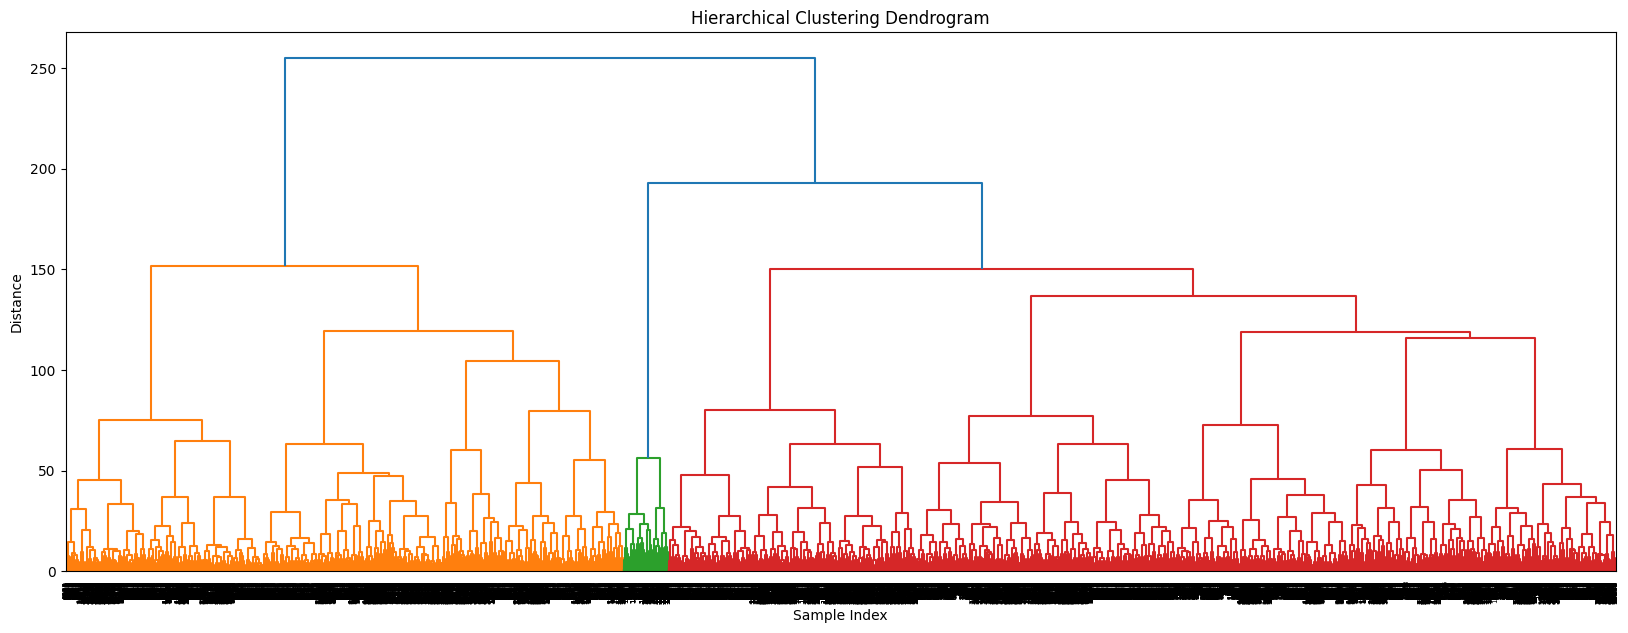

In [62]:
# ====================================================
# 9. Hierarchical Clustering
# ====================================================

linked = linkage(X_scaled_cleaned, 'ward')

plt.figure(figsize=(20,7))
dendrogram(linked)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

In [63]:
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df['Hierarchical_Cluster'] = hc.fit_predict(X_scaled_cleaned)

print('Hierarchical Clustering Results:')
print(df.groupby('Hierarchical_Cluster').mean())

Hierarchical Clustering Results:
                        season        yr  ...         cnt  KMeans_Cluster
Hierarchical_Cluster                      ...                            
0                     0.640358  0.508707  ...  234.723119        0.833200
1                     1.975421  0.498164  ...  164.318486        1.012525
2                     1.574850  0.522954  ...  156.984032        1.441118

[3 rows x 16 columns]


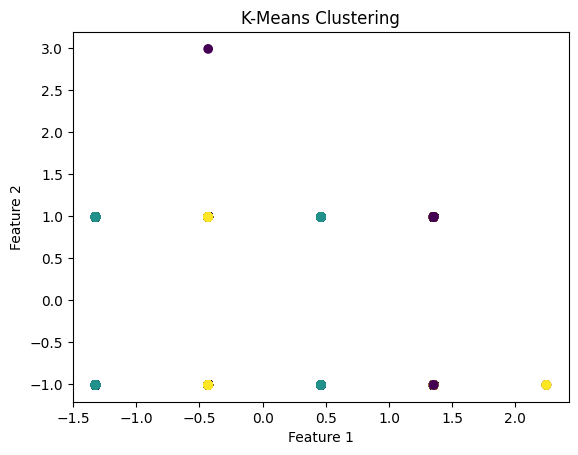

In [64]:
# ====================================================
# 10. Cluster Visualization (2 Features)
# ====================================================

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=df['KMeans_Cluster'])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering')
plt.show()

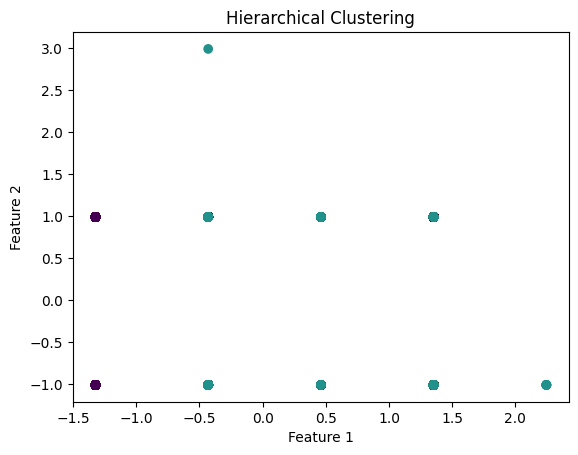

In [65]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=df['Hierarchical_Cluster'])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Hierarchical Clustering')
plt.show()

**Cluster Analysis and Interpretation:**

* Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.

### **Cluster Interpretation:**

1. **K-Means Clustering:**

* ***Cluster 0*** - represents low bike demand periods with lower temperature and fewer registered users.

* ***Cluster 1*** - represents medium demand periods with moderate weather conditions.

* ***Cluster 2*** - represents high demand periods with favorable weather and working days.

* Elbow method suggests 3 as the optimal number of clusters.

2. **Hierarchical Clustering:**

* Dendrogram shows clear separation into three major clusters.

* Ward linkage produces compact and well-separated clusters.

* Results are consistent with K-Means, confirming natural grouping in data.

3. **Insights:**

* Weather conditions and working days strongly influence bike demand.

* Clustering helps segment usage patterns for better planning and resource allocation.